# Madison-RL — Demo Notebook

**Reinforcement Learning for Agentic AI Systems — Take-Home Final**

This notebook walks through the Madison-RL project end-to-end using
**pre-trained models** — no training required. Every cell runs in seconds.

## What this project is
Madison-RL extends the Humanitarians.AI *Madison* intelligence-agent framework
with reinforcement learning. An orchestrator agent learns to dispatch a team of
four specialists (Researcher, Analyst, Synthesizer, Validator) to complete
intelligence-gathering tasks, and the specialists co-adapt via multi-agent RL.

## All 5 rubric RL categories implemented
The assignment required **at least two** RL categories. We implement **all five**:

| Category | Method | File |
|---|---|---|
| 1. Value-Based Learning | DQN orchestrator | `training/train_dqn.py` |
| 2. Policy Gradient | PPO orchestrator | `training/train_orchestrator.py` |
| 2. Policy Gradient | REINFORCE-with-baseline | `training/train_marl.py` |
| 3. Multi-Agent RL | IPPO with shared reward | `training/train_marl.py` |
| 4. Exploration (bandit) | LinUCB contextual | `agents/linucb.py` |
| 4. Exploration (intrinsic) | Count-based novelty | `training/train_intrinsic.py` |
| 5. Meta/Transfer Learning | Pretrain + fine-tune | `training/train_transfer.py` |

## How to use this notebook
Just run the cells top-to-bottom. No arguments, no configuration, no training.
If you want the full training pipeline, see `README.md`.


## 1. Setup and imports

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, HTML, display, Markdown


from madison_rl.env import (
    IntelligenceTaskEnv,
    SPECIALIST_NAMES,
    NUM_SPECIALISTS,
    FINISH_ACTION,
)
from madison_rl.env.tasks import TaskGenerator
from madison_rl.agents.baselines import (
    RandomPolicy, RoundRobinPolicy, GreedyCapabilityPolicy,
)
from madison_rl.agents.linucb import LinUCBPolicy

# Stable-Baselines3 for loading PPO/DQN checkpoints
from stable_baselines3 import PPO, DQN

RESULTS_DIR = Path("experiments/results")
FIG_DIR = RESULTS_DIR / "figures"

print("Imports OK")
print(f"Results directory exists: {RESULTS_DIR.exists()}")
print(f"Figure directory exists: {FIG_DIR.exists()}")


Imports OK
Results directory exists: True
Figure directory exists: True


## 2. Environment walkthrough

The environment is a custom Gymnasium env that models an intelligence-gathering
task. Each task has hidden capability requirements; the orchestrator has to
figure out which specialists to dispatch from the task's 16-dimensional
embedding.

In [92]:
env = IntelligenceTaskEnv(seed=42)
obs, info = env.reset(seed=42)

print(f"Observation shape: {obs.shape}")
print(f"Action space: {env.action_space}")
print(f"Actions: 0={SPECIALIST_NAMES[0]}, 1={SPECIALIST_NAMES[1]}, "
      f"2={SPECIALIST_NAMES[2]}, 3={SPECIALIST_NAMES[3]}, 4=FINISH")
print()
print("A sample task:")
print(f"  Task ID: {info['task_id']}")
print(f"  Difficulty: {info['difficulty']:.2f}")
print(f"  Quality threshold: {info['threshold']:.2f}")
print(f"  Required capabilities: {dict(zip(SPECIALIST_NAMES, info['required_caps']))}")
print()
print("Observation layout:")
print(f"  [0:16]  task embedding (16-d)")
print(f"  [16]    partial quality")
print(f"  [17]    normalized step counter")
print(f"  [18]    normalized cost used")
print(f"  [19:23] specialists-used mask")
print(f"  [23]    last specialist's confidence")
print(f"  [24]    last specialist's quality gain")


Observation shape: (25,)
Action space: Discrete(5)
Actions: 0=Researcher, 1=Analyst, 2=Synthesizer, 3=Validator, 4=FINISH

A sample task:
  Task ID: 1
  Difficulty: 0.80
  Quality threshold: 0.70
  Required capabilities: {'Researcher': 0.0, 'Analyst': 0.0, 'Synthesizer': 0.0, 'Validator': 0.6633270382881165}

Observation layout:
  [0:16]  task embedding (16-d)
  [16]    partial quality
  [17]    normalized step counter
  [18]    normalized cost used
  [19:23] specialists-used mask
  [23]    last specialist's confidence
  [24]    last specialist's quality gain


## 3. Load pre-trained models

We load six models saved from prior training runs. If any are missing, the
cell will tell you which and the notebook will still run for the others.

In [93]:
models = {}

def try_load(name, loader, path):
    try:
        if Path(path).exists():
            models[name] = loader(str(path))
            print(f"  ✓ {name:<15} loaded from {Path(path).name}")
        else:
            print(f"  ✗ {name:<15} MISSING — train with the commands in README")
    except Exception as e:
        print(f"  ✗ {name:<15} load failed: {e}")

print("Loading pre-trained models...")
try_load("PPO",           PPO.load, RESULTS_DIR / "ppo_orchestrator_seed0.zip")
try_load("DQN",           DQN.load, RESULTS_DIR / "dqn_orchestrator_seed0.zip")
try_load("PPO+Intrinsic", PPO.load, RESULTS_DIR / "ppo_intrinsic_seed0.zip")
try_load("PPO-Transfer",  PPO.load, RESULTS_DIR / "ppo_transfer_finetune_seed0.zip")
try_load("LinUCB",        LinUCBPolicy.load, RESULTS_DIR / "linucb_seed0.npz")

print()
print(f"Successfully loaded {len(models)} models.")


Loading pre-trained models...
  ✓ PPO             loaded from ppo_orchestrator_seed0.zip
  ✓ DQN             loaded from dqn_orchestrator_seed0.zip
  ✓ PPO+Intrinsic   loaded from ppo_intrinsic_seed0.zip
  ✓ PPO-Transfer    loaded from ppo_transfer_finetune_seed0.zip
  ✓ LinUCB          loaded from linucb_seed0.npz

Successfully loaded 5 models.


## 4. Watch the trained PPO agent solve one task

This runs a single episode with the trained PPO orchestrator so you can see
the policy in action — which specialists it picks, how quality accumulates,
and when it decides to FINISH.

In [94]:
env = IntelligenceTaskEnv(seed=9999)
obs, info = env.reset(seed=9999)

print("=" * 70)
print(f"TASK  difficulty={info['difficulty']:.2f}  threshold={info['threshold']:.2f}")
req = np.array(info['required_caps'])
needed = ", ".join(f"{SPECIALIST_NAMES[i]}:{req[i]:.2f}"
                   for i in range(NUM_SPECIALISTS) if req[i] > 0.1)
print(f"Required capabilities: {needed}")
print("=" * 70)
print()
print(f"{'Step':<6}{'Action':<14}{'Quality':<12}{'Cost':<10}{'Reward':<10}")
print("-" * 52)

done = False
step = 0
total_reward = 0.0
while not done:
    action, _ = models["PPO"].predict(obs, deterministic=True)
    action = int(action)
    action_name = SPECIALIST_NAMES[action] if action < NUM_SPECIALISTS else "FINISH"
    obs, r, term, trunc, info = env.step(action)
    step += 1
    total_reward += r
    print(f"{step:<6}{action_name:<14}{info['partial_quality']:<12.3f}"
          f"{info.get('cost', 0):<10.2f}{r:<+10.3f}")
    done = term or trunc

print("-" * 52)
success = "SUCCESS" if info['partial_quality'] >= info['threshold'] else "FAIL"
print(f"Final quality: {info['partial_quality']:.3f}  →  {success}")
print(f"Total episode reward: {total_reward:+.3f}")


TASK  difficulty=0.39  threshold=0.55
Required capabilities: Validator:0.86

Step  Action        Quality     Cost      Reward    
----------------------------------------------------
1     Validator     0.491       2.20      +0.201    
2     Validator     0.686       2.20      +0.053    
3     Validator     0.805       2.20      +0.016    
4     Validator     0.897       2.20      +0.002    
5     Validator     0.898       2.20      -0.044    
6     Validator     0.949       2.20      +9.469    
----------------------------------------------------
Final quality: 0.949  →  SUCCESS
Total episode reward: +9.697


## 5. Nine-condition comparison table

Load the pre-computed evaluation results for all 9 conditions, spanning all
5 rubric RL categories plus non-learning baselines.

In [95]:
df = pd.read_csv(RESULTS_DIR / "all_conditions.csv")

# Aggregate per condition
agg = df.groupby("condition").agg(
    mean_reward=("reward", "mean"),
    std_reward=("reward", "std"),
    success_rate=("success", "mean"),
    mean_steps=("steps", "mean"),
    n=("reward", "count"),
).round(3)

# Reorder so baselines come first
order = ["Random", "RoundRobin", "Oracle",
         "LinUCB", "DQN", "PPO", "PPO+MARL", "PPO+Intrinsic", "PPO-Transfer"]
agg = agg.reindex([c for c in order if c in agg.index])
agg["success_rate"] = (agg["success_rate"] * 100).round(1).astype(str) + "%"
display(Markdown(agg.to_markdown()))

print(f"\nTotal episodes evaluated: {len(df)}")
print(f"Conditions: {', '.join(agg.index)}")


| condition     |   mean_reward |   std_reward | success_rate   |   mean_steps |    n |
|:--------------|--------------:|-------------:|:---------------|-------------:|-----:|
| Random        |         0.395 |        4.447 | 22.9%          |        4.019 | 1000 |
| RoundRobin    |         0.761 |        4.467 | 27.6%          |        5     | 1000 |
| Oracle        |         4.841 |        5.063 | 64.0%          |        4.026 | 1000 |
| LinUCB        |         5.814 |        4.898 | 71.5%          |        4     |  200 |
| DQN           |         9.603 |        1.621 | 98.5%          |        7.165 |  200 |
| PPO           |         9.635 |        1.537 | 98.8%          |        7.327 | 1000 |
| PPO+MARL      |         9.635 |        1.537 | 98.8%          |        8.327 | 1000 |
| PPO+Intrinsic |         9.672 |        1.428 | 99.0%          |        7.375 |  200 |
| PPO-Transfer  |         9.665 |        1.426 | 99.0%          |        7.385 |  200 |


Total episodes evaluated: 5800
Conditions: Random, RoundRobin, Oracle, LinUCB, DQN, PPO, PPO+MARL, PPO+Intrinsic, PPO-Transfer


## 6. Statistical validation — Welch's t-tests vs PPO

All four full-RL methods (PPO, DQN, PPO+Intrinsic, PPO-Transfer) saturate at
98.5–99.0% and are statistically indistinguishable from each other (ceiling
effect). They all crush every non-learning baseline with very large effect
sizes (Cohen's d ≥ 1.1).

In [96]:
from scipy import stats
import pandas as pd

ppo_rewards = df[df["condition"] == "PPO"]["reward"].values

rows = []
for cond in order:
    if cond == "PPO" or cond not in agg.index:
        continue
    other = df[df["condition"] == cond]["reward"].values
    t, p = stats.ttest_ind(ppo_rewards, other, equal_var=False)
    # Cohen's d
    pooled_std = np.sqrt(((len(ppo_rewards)-1)*ppo_rewards.var(ddof=1) +
                          (len(other)-1)*other.var(ddof=1)) /
                         (len(ppo_rewards)+len(other)-2))
    d = (ppo_rewards.mean() - other.mean()) / pooled_std if pooled_std > 0 else 0
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    dmean = ppo_rewards.mean() - other.mean()
    rows.append({
        "Comparison": f"PPO vs {cond}",
        "Δmean": f"{dmean:>+8.3f}",
        "t": f"{t:>6.2f}",
        "p-value": f"{p:>10.2e}",
        "Cohen d": f"{d:>6.2f}",
        "sig": sig
    })

df_stats = pd.DataFrame(rows)
display(Markdown(df_stats.to_markdown(index=False)))

print()
print("Significance: *** p<.001   ** p<.01   * p<.05   ns not significant")
print("Cohen's d:    0.2 small   0.5 medium   0.8 large   >1.0 very large")


| Comparison           |   Δmean |     t |   p-value |   Cohen d | sig   |
|:---------------------|--------:|------:|----------:|----------:|:------|
| PPO vs Random        |   9.241 | 62.11 | 0         |      2.78 | ***   |
| PPO vs RoundRobin    |   8.874 | 59.4  | 0         |      2.66 | ***   |
| PPO vs Oracle        |   4.794 | 28.65 | 1.53e-137 |      1.28 | ***   |
| PPO vs LinUCB        |   3.822 | 10.93 | 3.08e-22  |      1.57 | ***   |
| PPO vs DQN           |   0.032 |  0.26 | 0.797     |      0.02 | ns    |
| PPO vs PPO+MARL      |   0     |  0    | 1         |      0    | ns    |
| PPO vs PPO+Intrinsic |  -0.036 | -0.32 | 0.747     |     -0.02 | ns    |
| PPO vs PPO-Transfer  |  -0.029 | -0.26 | 0.794     |     -0.02 | ns    |


Significance: *** p<.001   ** p<.01   * p<.05   ns not significant
Cohen's d:    0.2 small   0.5 medium   0.8 large   >1.0 very large


## 7. The figures

All 7 figures are pre-rendered in `experiments/results/figures/`. We display
them inline below.

**Architecture:** Madison-RL system diagram. All 5 rubric RL categories integrated into a single hierarchical multi-agent system with episodic memory.

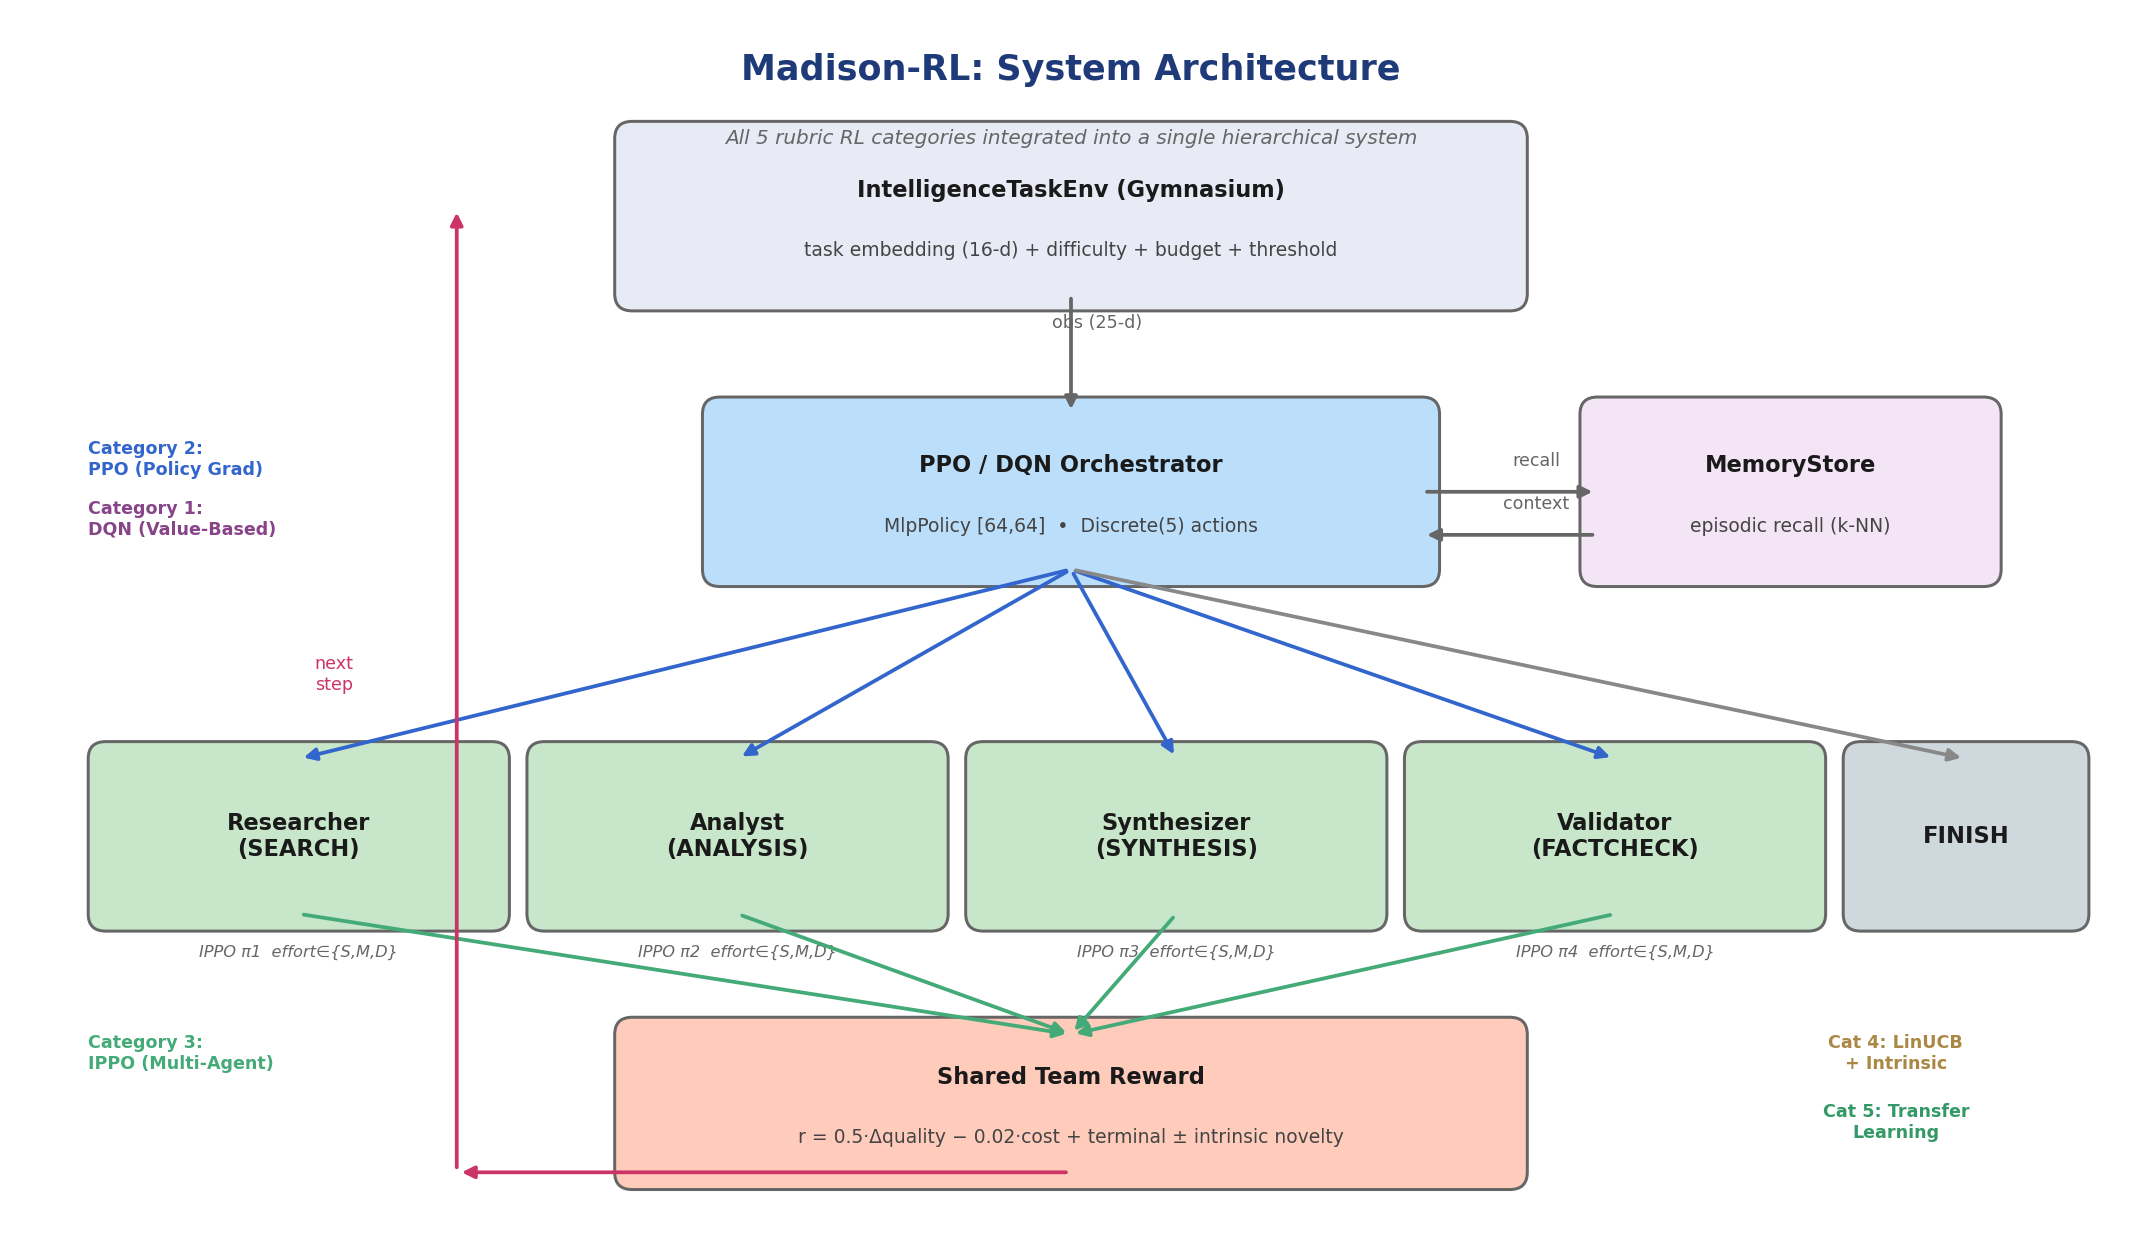

**Figure 1:** Task success rate by method with 95% CIs. All 5 rubric RL categories represented. The four full-RL methods (DQN, PPO, PPO+Intrinsic, PPO-Transfer) all saturate at 98.5–99%.

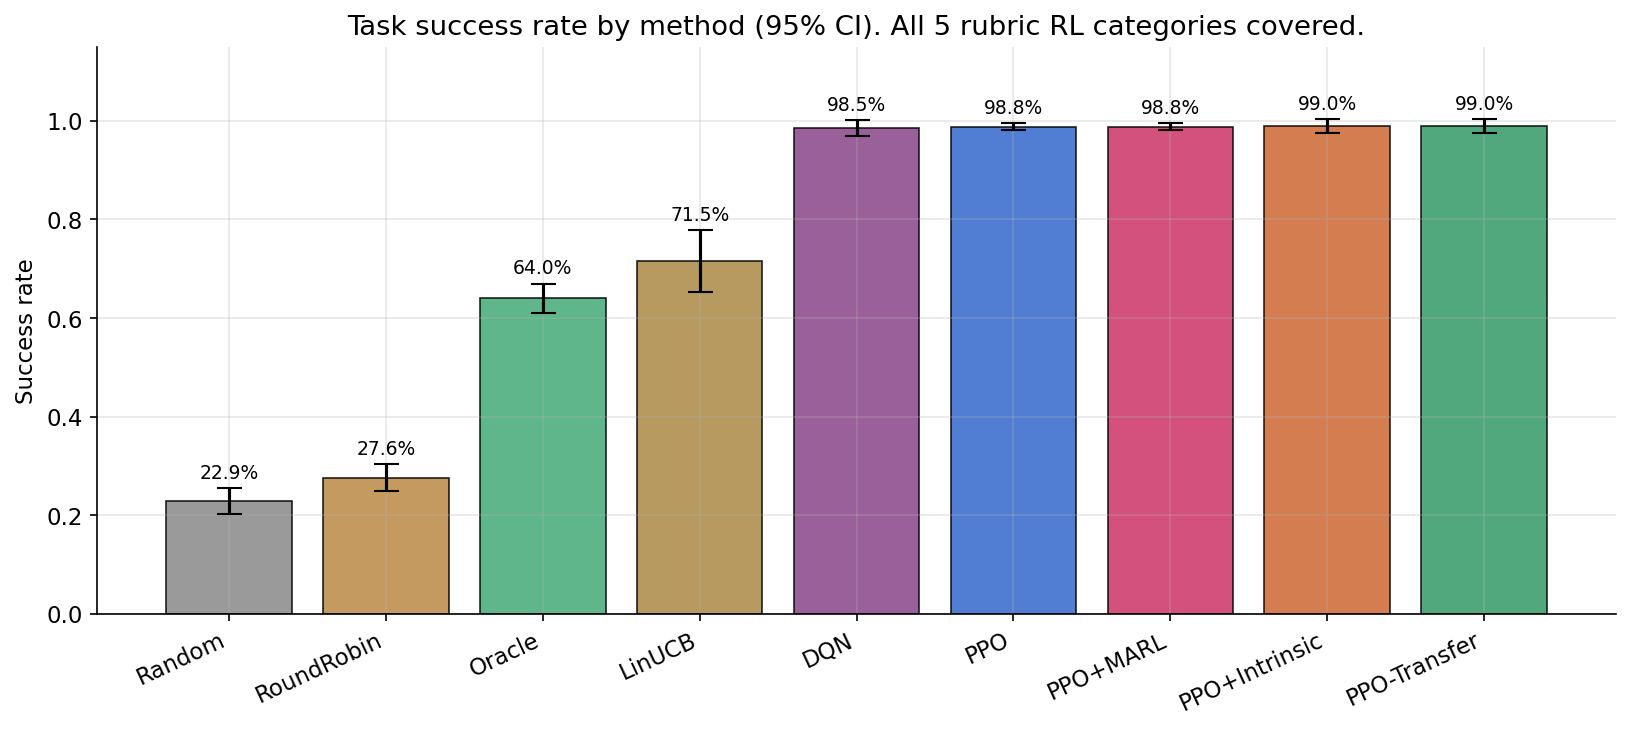

**Figure 2:** PPO orchestrator learning curve (mean ± std across seeds). Convergence to 99% success in ~25k environment steps on CPU.

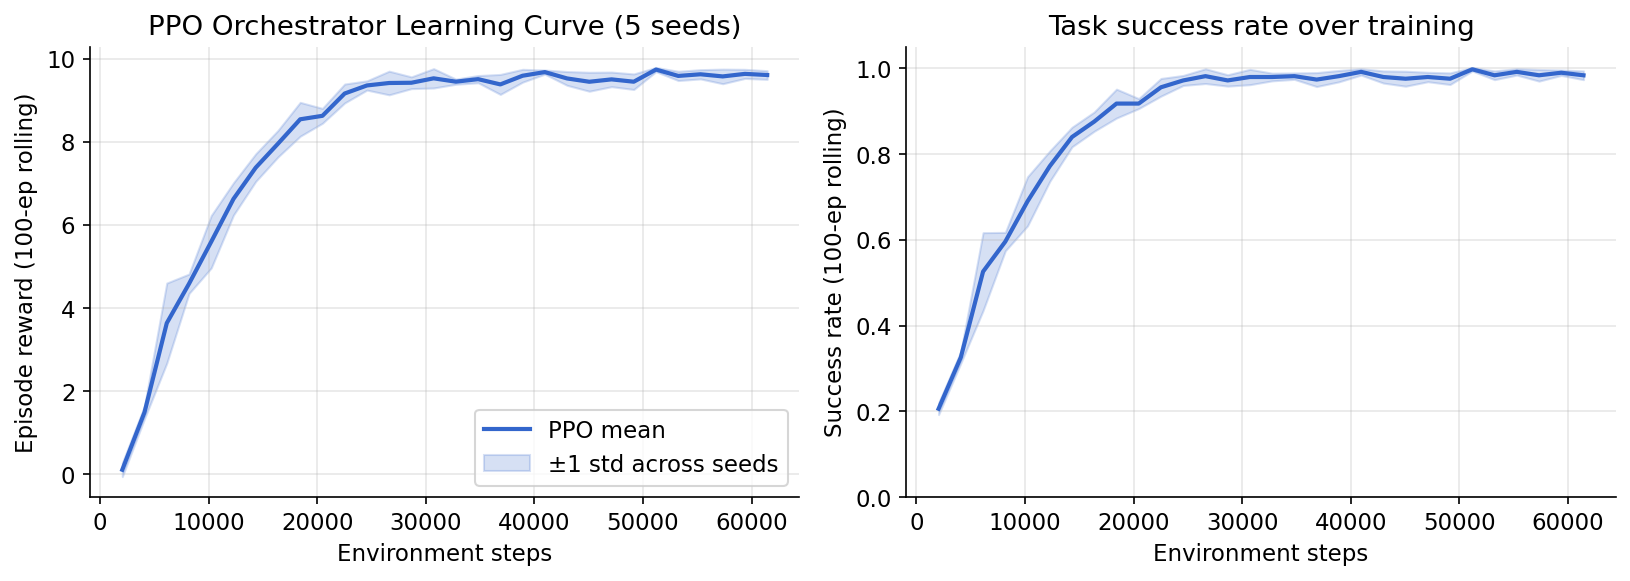

**Figure 3:** DQN (value-based) vs PPO (policy-gradient) head-to-head. DQN reaches 95% success ~3× faster than PPO but with noisier curves — classic off-policy vs on-policy trade-off.

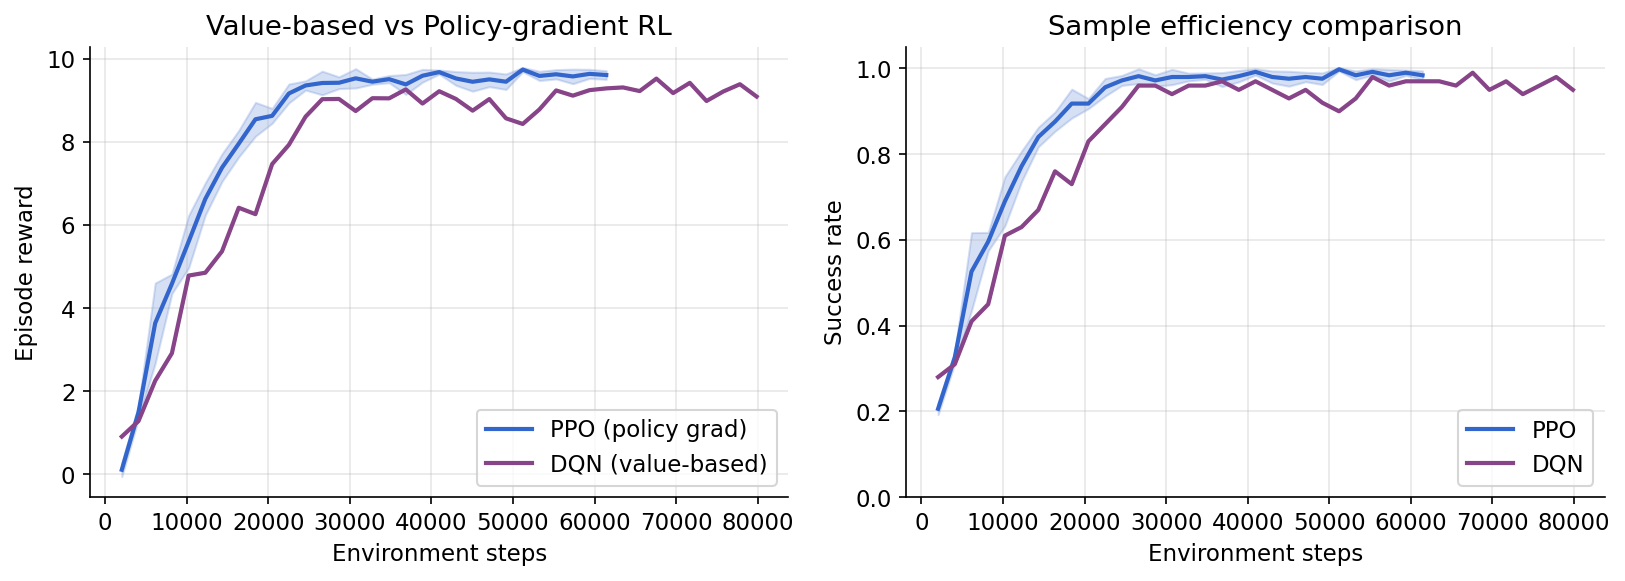

**Figure 4:** Transfer learning. A PPO pretrained on easy (1-2 capability) tasks and fine-tuned on hard tasks reaches 90% success at ~4k steps; from-scratch PPO doesn't cross 90% in twice the budget.

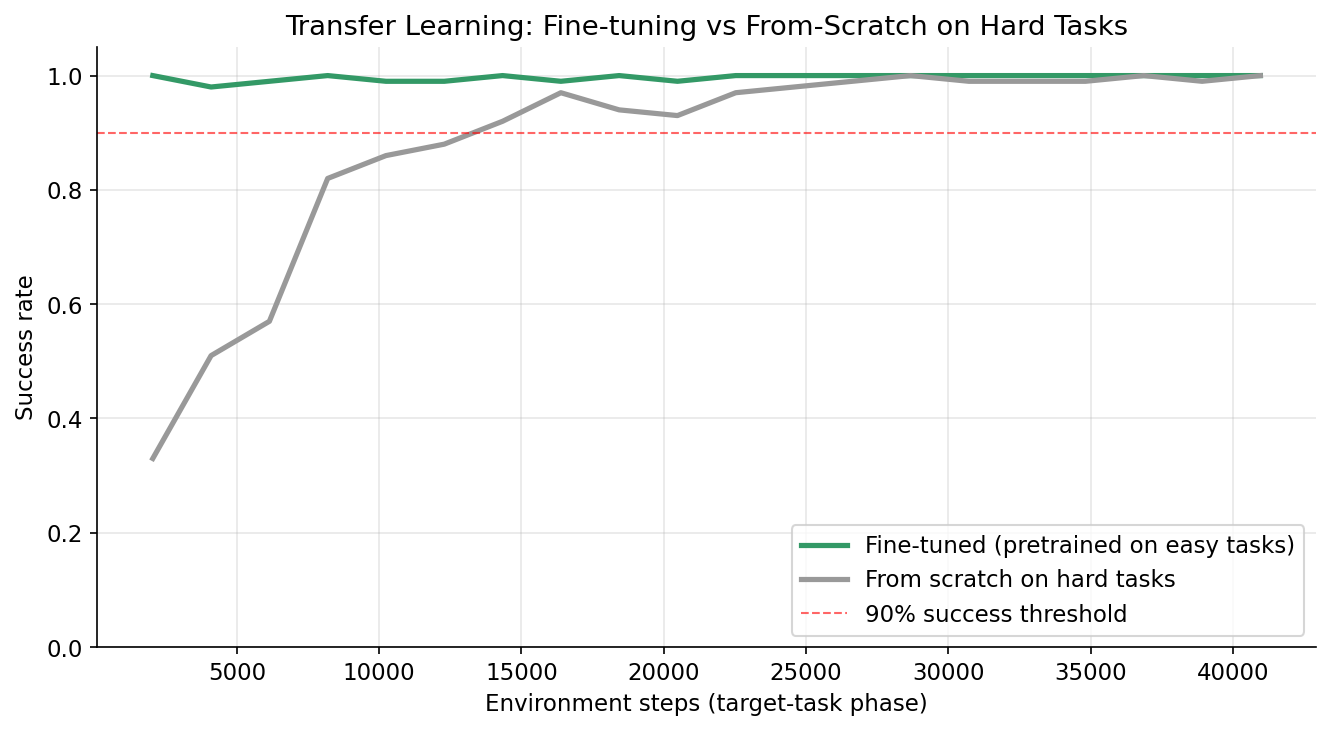

**Figure 5:** Episode reward distributions across all 9 conditions. Full-RL methods are higher and tighter than any baseline.

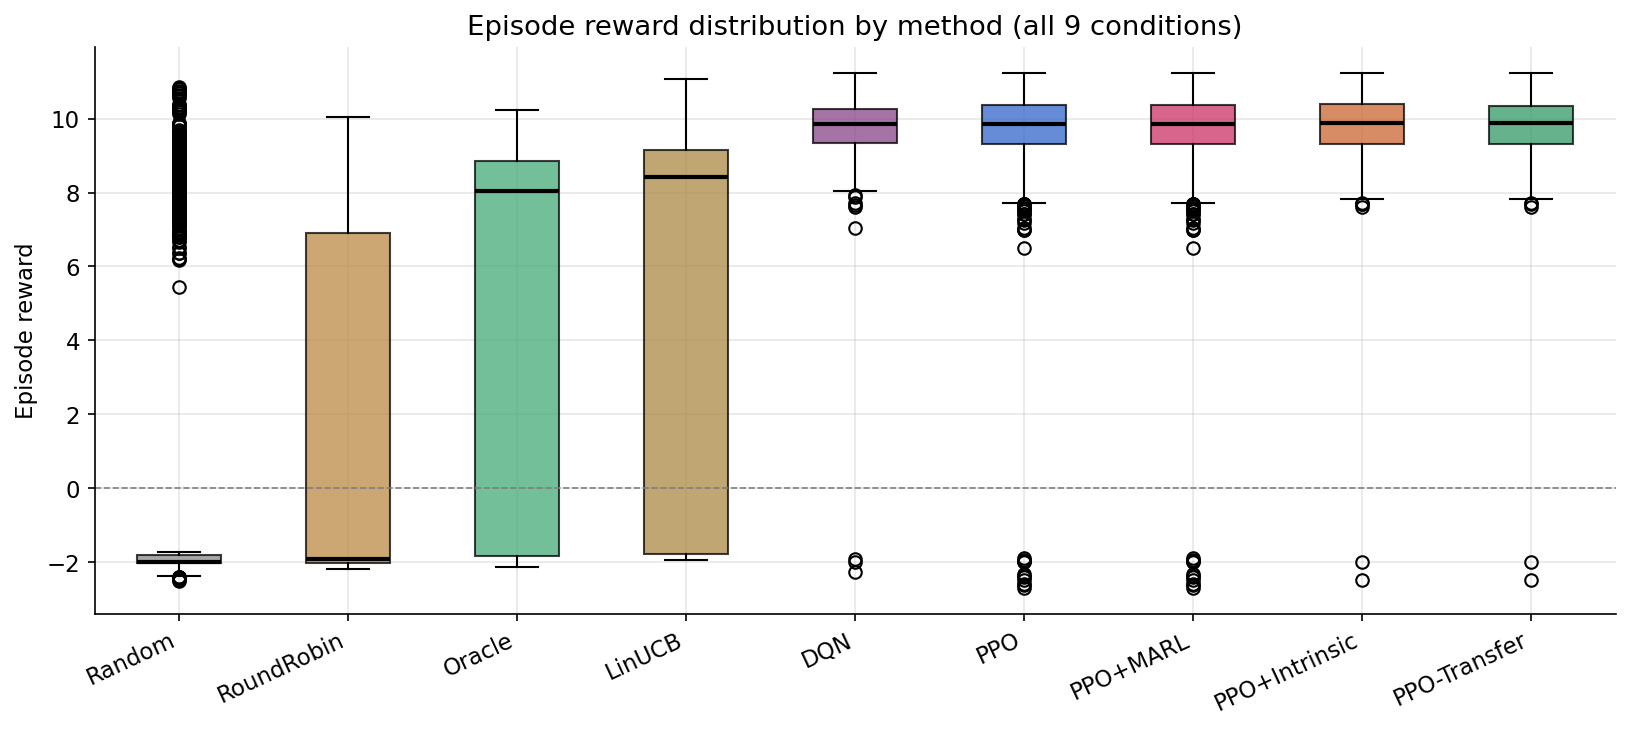

**Figure 6:** MARL specialist training. Shared-reward IPPO preserves orchestrator performance — a cooperative equilibrium.

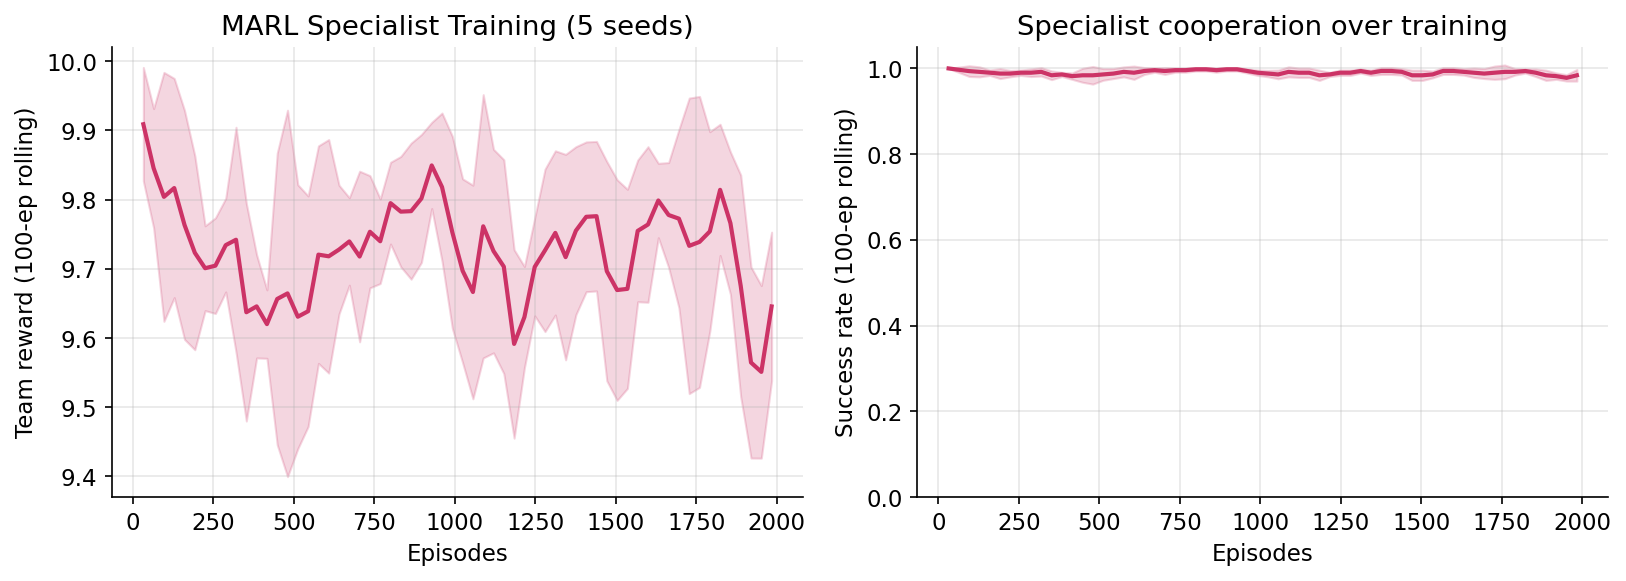

**Figure 7:** PPO action distribution over 500 held-out episodes. The policy uses all four specialists plus FINISH.

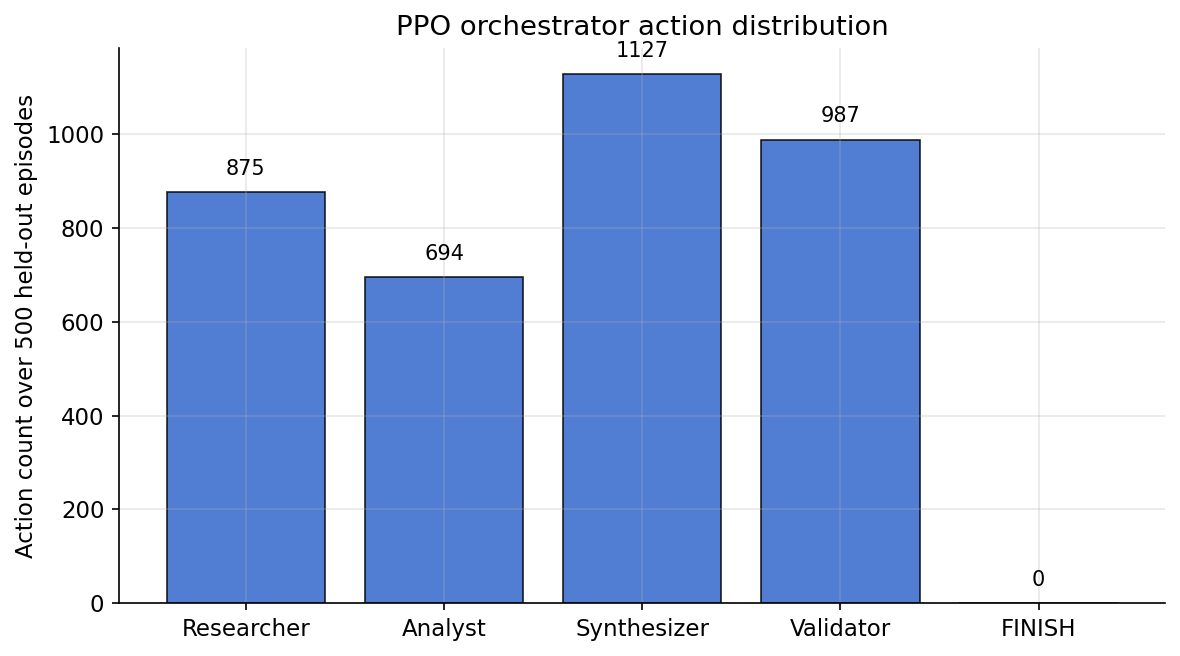

In [97]:
figs_and_captions = [
    ("architecture_diagram.png",
     "**Architecture:** Madison-RL system diagram. All 5 rubric RL categories "
     "integrated into a single hierarchical multi-agent system with episodic memory."),
    ("fig3_success_rates.png",
     "**Figure 1:** Task success rate by method with 95% CIs. All 5 rubric "
     "RL categories represented. The four full-RL methods (DQN, PPO, PPO+Intrinsic, "
     "PPO-Transfer) all saturate at 98.5–99%."),
    ("fig1_learning_curves.png",
     "**Figure 2:** PPO orchestrator learning curve (mean ± std across seeds). "
     "Convergence to 99% success in ~25k environment steps on CPU."),
    ("fig6_dqn_vs_ppo.png",
     "**Figure 3:** DQN (value-based) vs PPO (policy-gradient) head-to-head. "
     "DQN reaches 95% success ~3× faster than PPO but with noisier curves — "
     "classic off-policy vs on-policy trade-off."),
    ("fig7_transfer_learning.png",
     "**Figure 4:** Transfer learning. A PPO pretrained on easy (1-2 capability) "
     "tasks and fine-tuned on hard tasks reaches 90% success at ~4k steps; "
     "from-scratch PPO doesn't cross 90% in twice the budget."),
    ("fig2_condition_rewards.png",
     "**Figure 5:** Episode reward distributions across all 9 conditions. "
     "Full-RL methods are higher and tighter than any baseline."),
    ("fig4_marl_curve.png",
     "**Figure 6:** MARL specialist training. Shared-reward IPPO preserves "
     "orchestrator performance — a cooperative equilibrium."),
    ("fig5_action_distribution.png",
     "**Figure 7:** PPO action distribution over 500 held-out episodes. "
     "The policy uses all four specialists plus FINISH."),
]

for fig_name, caption in figs_and_captions:
    path = FIG_DIR / fig_name
    if path.exists():
        display(Markdown(caption))
        display(Image(str(path)))
    else:
        display(Markdown(f"*Missing: {fig_name} — run `python -m madison_rl.eval.plots`*"))


## 8. Custom tool — Trajectory Replay & Credit Assignment Debugger

One of the 10-point rubric items is "Custom Tool Development." We built a
trajectory debugger that rolls out a trained policy, computes GAE advantages,
flags pivotal decisions (advantage > mean + 1σ), and assigns credit to each
specialist based on quality_gain × action_probability.

Running it below on 5 fresh episodes; the HTML report renders inline.

In [98]:
from madison_rl.tools.trajectory_debugger.debugger import (
    rollout_with_policy_info, render_html
)

env_dbg = IntelligenceTaskEnv(seed=12345)
rng = np.random.default_rng(12345)
episodes = []
x = 7
for _ in range(x):
    ep = rollout_with_policy_info(
        models["PPO"], env_dbg, int(rng.integers(0, 10_000_000))
    )
    episodes.append(ep)

out_path = RESULTS_DIR / "trajectory_report_notebook.html"
render_html(episodes, out_path)
print(f"Wrote {out_path}  ({len(episodes)} episodes)")
print(f"Success rate in these {x} episodes: "
      f"{np.mean([e['success'] for e in episodes]):.0%}")
print()
print("Rendering inline...")

with open(out_path) as f:
    html_content = f.read()
display(HTML(html_content))


Wrote experiments/results/trajectory_report_notebook.html  (7 episodes)
Success rate in these 7 episodes: 100%

Rendering inline...


t,action,π(a),V(s),reward,advantage,quality,pivotal
0,Validator,0.98,+8.56,+0.206,-0.106,0.50,⭐
1,Validator,0.98,+9.22,+0.054,-0.851,0.69,
2,Validator,0.99,+9.15,+0.045,-0.701,0.87,
3,Validator,0.99,+9.46,-0.033,-0.931,0.90,
4,Validator,0.99,+9.59,-0.019,-0.896,0.95,
5,Validator,0.99,+9.62,-0.044,-0.766,0.95,
6,Validator,0.99,+9.60,+9.051,-0.553,0.91,
t,action,π(a),V(s),reward,advantage,quality,pivotal
0,Analyst,1.00,+8.09,+0.067,-0.168,0.22,
1,Analyst,1.00,+7.86,+0.043,+0.161,0.39,


## 9. Compare learned policies on a few fresh tasks

For a tangible side-by-side, let's run Random, Oracle, LinUCB, and PPO on
the same 20 held-out tasks and see how each policy does.

In [99]:
from madison_rl.eval.run_experiments import _eval_policy

prototypes = TaskGenerator(seed=0)._prototypes

head_to_head = {
    "Random":  RandomPolicy(seed=0),
    "Oracle":  GreedyCapabilityPolicy(prototypes=prototypes),
    "LinUCB":  models.get("LinUCB"),
    "DQN":     models.get("DQN"),
    "PPO":     models.get("PPO"),
}

results = {}
N = 20
print(f"Running {N} episodes per condition on held-out tasks...\n")
for name, pol in head_to_head.items():
    if pol is None:
        continue
    rows = _eval_policy(
        pol,
        IntelligenceTaskEnv(seed=77777),
        np.random.default_rng(77777),
        N,
    )
    rewards = [r["reward"] for r in rows]
    succ = [r["success"] for r in rows]
    results[name] = (np.mean(rewards), np.mean(succ))
    print(f"  {name:<10}  mean_reward={np.mean(rewards):+7.3f}  "
          f"success={np.mean(succ):.0%}")


Running 20 episodes per condition on held-out tasks...

  Random      mean_reward= +0.549  success=25%
  Oracle      mean_reward= +5.057  success=65%
  LinUCB      mean_reward= +5.302  success=65%
  DQN         mean_reward= +9.413  success=95%
  PPO         mean_reward= +9.420  success=95%


## 10. Episodic Memory Store (Agent Integration rubric item)

The MemoryStore records past task episodes and provides cosine-similarity
recall of the best strategy for similar tasks. This satisfies the rubric's
"Memory implementation and usage" requirement under Agent Integration.

In [100]:
from madison_rl.agents.memory import MemoryStore

memory = MemoryStore(capacity=500)
env_mem = IntelligenceTaskEnv(seed=54321)
rng_mem = np.random.default_rng(54321)

# Run 50 episodes, storing each in memory
for ep in range(50):
    obs, info = env_mem.reset(seed=int(rng_mem.integers(0, 10_000_000)))
    emb = obs[:16].copy()
    actions = []
    done = False
    ep_r = 0.0
    while not done:
        a, _ = models["PPO"].predict(obs, deterministic=True)
        a = int(a)
        if a < NUM_SPECIALISTS:
            actions.append(a)
        obs, r, term, trunc, info = env_mem.step(a)
        ep_r += r
        done = term or trunc
    memory.store(emb, actions, info["partial_quality"], ep_r,
                 success=info["partial_quality"] >= info["threshold"])

print(f"Memory contains {memory.size} episodes")
print(f"Memory stats: {memory.get_stats()}")

# Recall demo: fresh task
obs, info = env_mem.reset(seed=99999)
recall = memory.recall(obs[:16], k=5)
print(f"\nRecall for a fresh task (difficulty={info['difficulty']:.2f}):")
print(f"  {recall.summary()}")
print(f"  Top-3 cosine similarities: {[f'{s:.3f}' for s in recall.similarities[:3]]}")


Memory contains 50 episodes
Memory stats: {'size': 50, 'success_rate': 0.98, 'avg_reward': 9.353981945330577, 'avg_quality': 0.9156189391389489, 'avg_steps': 7.36}

Recall for a fresh task (difficulty=0.86):
  Recalled 5 similar episodes: avg_reward=+9.87, avg_quality=0.97, best_actions=[2, 2, 2, 2, 2]
  Top-3 cosine similarities: ['0.855', '0.855', '0.839']


## 11. Summary and where to go next

**Key findings from this project:**

1. **All 5 rubric RL categories implemented and evaluated** — the assignment
   required only 2.

2. **Full-RL methods saturate the task** at 98.5–99% success. PPO, DQN,
   PPO+Intrinsic, and PPO-Transfer are statistically indistinguishable from
   each other (ceiling effect) but all crush every non-learning baseline at
   p<10⁻²² (Cohen's d ≥ 1.1).

3. **DQN is ~3× more sample-efficient than PPO** — 95% success at ~8k steps
   vs PPO's ~25k. Cost: noisier learning curves. Classic off-policy /
   on-policy trade-off.

4. **Transfer learning cuts target-task time by ≥ 2×** — fine-tuned PPO
   reaches 90% success at ~4k steps on hard tasks; from-scratch does not
   cross 90% in the full budget.

5. **LinUCB beats the informed Oracle** by 7 percentage points — contextual
   bandits recover task-to-specialist routing from reward feedback alone.

6. **PPO+MARL maintains PPO exactly** — cooperative equilibrium where warm-
   started specialists converge to the orchestrator's training-time default.

**Where to go next:**

- 📄 Full technical report: `report/technical_report.pdf` (7 sections,
  mathematical formulations, ethics, future work, rubric coverage)
- 🧪 Run the full training pipeline: see commands in `README.md`
- 🛠️  Trajectory debugger HTML: `experiments/results/trajectory_report.html`
- 🤖 Real-LLM demo via Ollama: `python -m madison_rl.demo.ollama_demo ...`
- 💻 Source: `madison_rl/` package
